In [3]:
%matplotlib ipympl
from IPython.display import Image, display
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ipywidgets import interact, IntSlider
import matplotlib.ticker as ticker
import numba
from numba import njit, prange
import pickle
import os

### Ancilla Initialization and H_coll 

In [4]:
# path = '/home/francesco/Collisional_Methods/Documents/Notes_for_thesis/Immagini/Initialization_angle.png'
# display(Image(filename=path, width=800))

In [5]:
# =====
# Array
# =====
alpha_list = np.arange(0, 91, 0.1) 
phi_list = np.zeros(len(alpha_list))
theta_list = np.zeros(len(alpha_list))

P_0_list = np.zeros(len(alpha_list))
P_1_list = np.zeros(len(alpha_list))

# ==========
# Parameters
# ==========

cj = 0.01
dt = 0.01


In [6]:
# ===========
# Calculation
# ===========

n_points = len(alpha_list)

@njit(cache=True)
def compute_probability(alpha_list, n_points, cj, dt, phi_list, theta_list, P_0_list, P_1_list):
    
    for i in range(n_points):
        # -----------------
        # Angles definition
        # -----------------
        theta_list[i] = np.radians(alpha_list[i])    # z/x angle respect to z axis
        phi_list[i] = theta_list[i] - np.pi/2   # +z/-z angle  
    
        # ------------ 
        # g parameters
        # ------------
        g_z = np.cos(theta_list[i])
        g_x = np.sin(theta_list[i])
        g_0 = np.cos(phi_list[i]/2)
        g_1 = np.sin(phi_list[i]/2)
    
        # -------------
        # Probabilities
        # -------------
        P_0_list[i] = (g_0**2) * (np.cos(cj*dt))**2 + ((g_0 * g_z + g_1 * g_x)**2) * (np.sin(cj*dt))**2
        
        P_1_list[i] = (g_1**2) * (np.cos(cj*dt))**2 + ((g_0 * g_x - g_1 * g_z)**2) * (np.sin(cj*dt))**2

    return P_0_list, P_1_list

In [7]:
P0, P1 = compute_probability(alpha_list, n_points, cj, dt, phi_list, theta_list, P_0_list, P_1_list)

P_0_square = P0**2
P_1_square = P1**2

prob = P_0_square + P_1_square


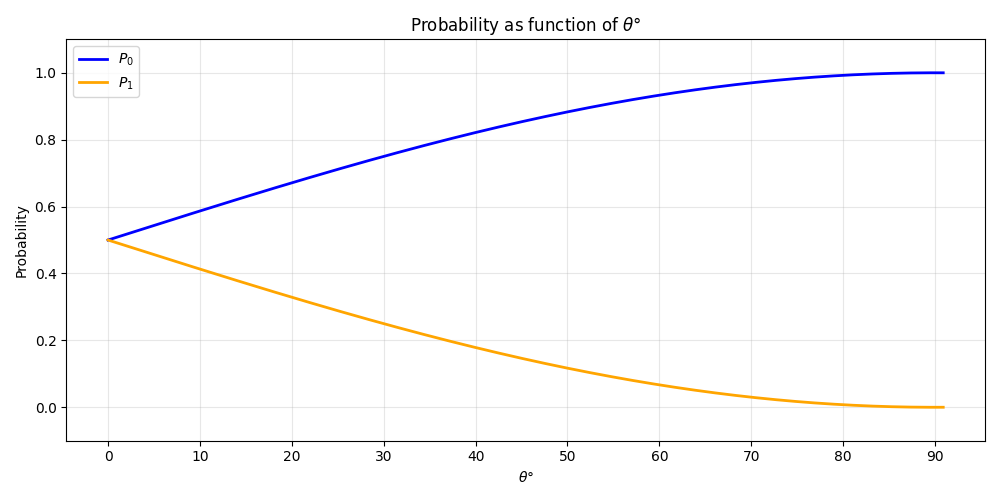

In [14]:
plt.close('all') 

path_imm = '/home/francesco/Collisional_Methods/Codes/Results/Plot'
#save_file = os.path.join(path_imm, "Prob(theta).png")

plt.close('all')

fig01, ax = plt.subplots(figsize = (10,5)) 

ax.plot(alpha_list, P0, label='$P_0$', linewidth=2, color='blue')
ax.plot(alpha_list, P1, label='$P_1$', linewidth=2, color='orange')

ax.set_title(r'Probability as function of $\theta$°')
ax.set_xlabel(r'$\theta°$')
ax.set_ylabel('Probability')
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.set_ylim(-0.1, 1.1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

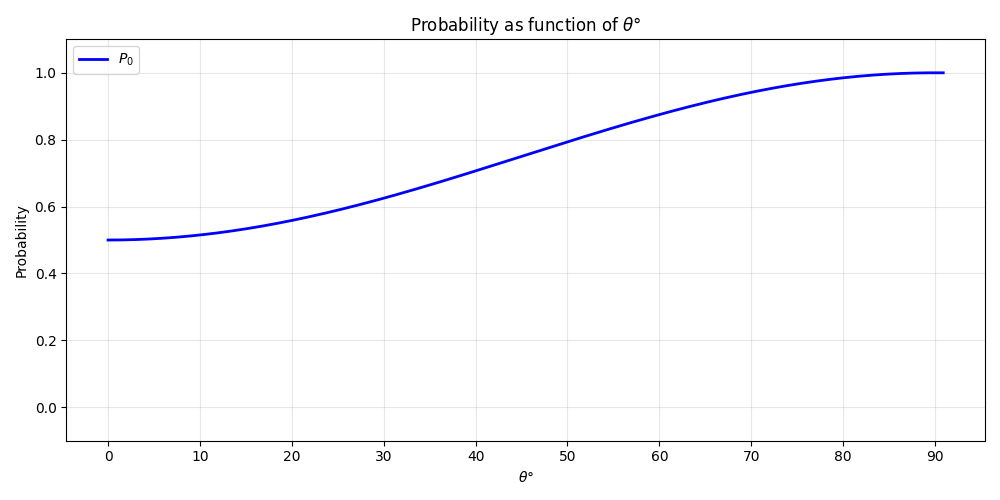

In [9]:
path_imm = '/home/francesco/Collisional_Methods/Codes/Results/Plot'
#save_file = os.path.join(path_imm, "Prob(theta).png")

plt.close('all')

fig02, ax = plt.subplots(figsize = (10,5)) 

ax.plot(alpha_list, prob, label='$P_0$', linewidth=2, color='blue')


ax.set_title(r'Probability as function of $\theta$°')
ax.set_xlabel(r'$\theta°$')
ax.set_ylabel('Probability')
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.set_ylim(-0.1, 1.1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

### Plot of Eq. 112 - 113 Fidelity of M0 and M1

Calculation of those quantities that defines how much the \textit{wf} is similar to itself after the evolution via $ \mathcal{M}_0 $ and $ \mathcal{M}_1 $ (related to the *wf* Modification Intensity), defined by the overlap of the two *wf*:
	  \begin{align}
	  	\left| \braket{\Psi_{S}^{PRE} | \Psi_{S}^{POST}}_{\mathcal{M}_{0}} \right|^2 = \left| \bra{\Psi_{S}}\mathcal{M}_0 \ket{\Psi_{S}} \right|^2 &= g_0^2 \cos^2{\left(c_j \Delta t \right)} + \left( 1 - g_0^2 \right) \sin^2{\left(c_j \Delta t \right)} \left| \braket{\sigma_{z}^{j}} \right|^2 \\
	  	\left| \braket{\Psi_{S}^{PRE} | \Psi_{S}^{POST}}_{\mathcal{M}_{1}} \right|^2 = \left| \bra{\Psi_{S}}\mathcal{M}_1 \ket{\Psi_{S}} \right|^2 &= \left( 1 - g_0^2 \right) \cos^2{\left(c_j \Delta t \right)} + g_0^2 \sin^2{\left(c_j \Delta t \right)} \left| \braket{\sigma_{z}^{j}} \right|^2
	  \end{align}
	  where 
	  \begin{equation*}
		\left| \braket{\sigma_{z}^{j}} \right|^2 = \left| \bra{\Psi_{S}} \sigma_{z}^{j} \ket{\Psi_{S}} \right|^2
	  \end{equation*}
that could vary between 1 and 0. <br>
Or in this other configuration a funztion of the $ \phi $ angle : 
    \begin{align}
	  	\left| \braket{\Psi_{S}^{PRE} | \Psi_{S}^{POST}}_{\mathcal{M}_{0}} \right|^2 = \left| \bra{\Psi_{S}}\mathcal{M}_0 \ket{\Psi_{S}} \right|^2 &= \cos \left( \phi/2 \right)^2 \cos^2{\left(c_j \Delta t \right)} + \left( 1 - \cos \left( \phi/2 \right)^2 \right) \sin^2{\left(c_j \Delta t \right)} \left| \braket{\sigma_{z}^{j}} \right|^2 \\
	  	\left| \braket{\Psi_{S}^{PRE} | \Psi_{S}^{POST}}_{\mathcal{M}_{1}} \right|^2 = \left| \bra{\Psi_{S}}\mathcal{M}_1 \ket{\Psi_{S}} \right|^2 &= \left( 1 - \cos \left( \phi/2 \right)^2 \right) \cos^2{\left(c_j \Delta t \right)} + \cos \left( \phi/2 \right)^2 \sin^2{\left(c_j \Delta t \right)} \left| \braket{\sigma_{z}^{j}} \right|^2
	  \end{align}
Where $ \phi $ is the angle that defines the Initial Ancilla's State. <br>
Setting $ c_j \Delta t = 0.001$ we could plot the trend as a function of $ \left| \braket{\sigma_{z}^{j}} \right|^2 $ and $ g_0^2 $ or the angle $ \phi $.

In [10]:
# ===========
# Calculation
# ===========

# ---------------------
# Sz expectation values
# ---------------------
sz = np.linspace(-1, 1, 200)   # varies from 0 to 1 

g0 = np.linspace(0, 1, 100)

n_points = len(g0)
m_points = len(sz)

F_M0_matrix = np.zeros((n_points, m_points))
F_M1_matrix = np.zeros((n_points, m_points))

G0, SZ = np.meshgrid(g0, sz, indexing='ij')

@njit(cache=True)
def compute_Fidelity(n_points, m_points, cj, dt, g0, sz, F_M0_matrix, F_M1_matrix):

    # Precompute constants to save time in loops
    cos2_cdt = (np.cos(cj * dt))**2
    sin2_cdt = (np.sin(cj * dt))**2
    
    for i in range(n_points):
        # Calculate squared g parameters
        g0_sq = g0[i]**2
        g1_sq = 1 - g0[i]**2
        for j in range(m_points):
            sz_sq = sz[j]**2
            
            # Fidelity for M0
            F_M0_matrix[i, j] = g0_sq * cos2_cdt + g1_sq * sin2_cdt * sz_sq
            
            # Fidelity for M1
            F_M1_matrix[i, j] = g1_sq * cos2_cdt + g0_sq * sin2_cdt * sz_sq

    return F_M0_matrix, F_M1_matrix

F_M0_matrix, F_M1_matrix = compute_Fidelity(n_points, m_points, cj, dt, g0, sz, F_M0_matrix, F_M1_matrix)

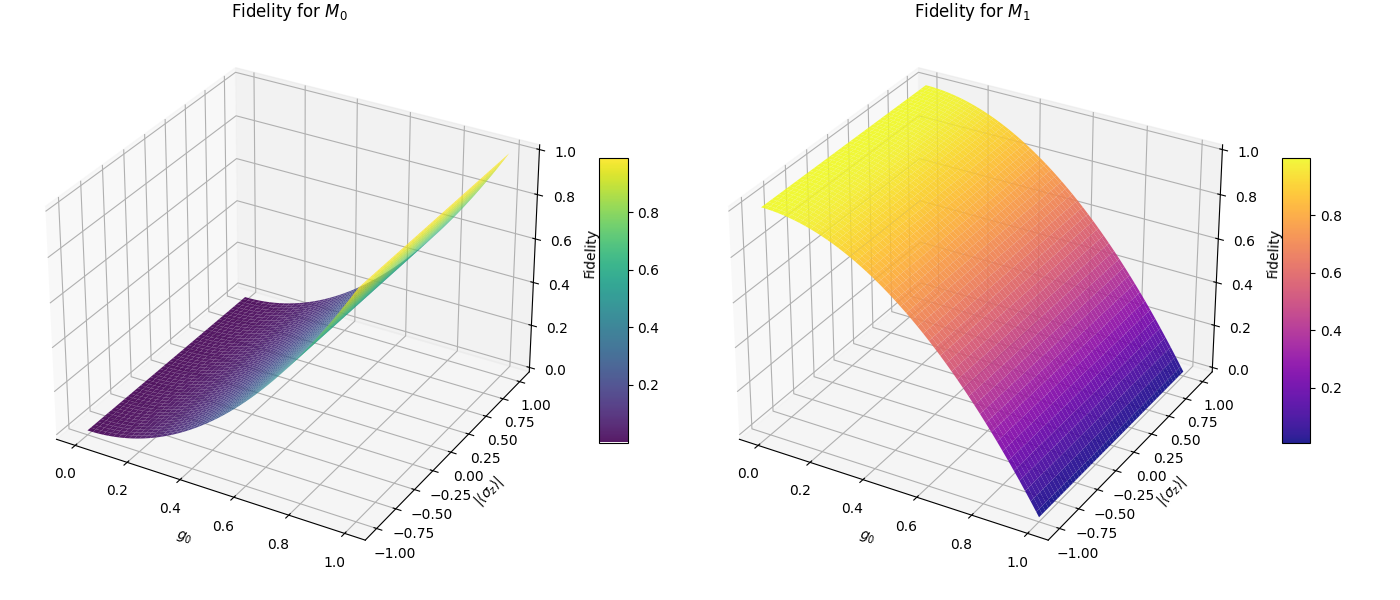

interactive(children=(IntSlider(value=100, description='Sz Index', max=199), Output()), _dom_classes=('widget-…

interactive(children=(IntSlider(value=50, description='g0 Index', max=99), Output()), _dom_classes=('widget-in…

<function __main__.plot_fixed_g0(g0_idx)>

In [15]:
# ==========================
# 1. 3D Surface Plots
# ==========================
fig = plt.figure(figsize=(14, 6))

# Plot for F_M0
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(G0, SZ, F_M0_matrix, cmap='viridis', alpha=0.9)
ax1.set_xlabel('$g_0$')
ax1.set_ylabel('$|\\langle \\sigma_z \\rangle|$')
ax1.set_zlabel('Fidelity')
ax1.set_title('Fidelity for $M_0$')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# Plot for F_M1
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(G0, SZ, F_M1_matrix, cmap='plasma', alpha=0.9)
ax2.set_xlabel('$g_0$')
ax2.set_ylabel('$|\\langle \\sigma_z \\rangle|$')
ax2.set_zlabel('Fidelity')
ax2.set_title('Fidelity for $M_1$')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

# ==========================
# 2. 2D Interactive Plots
# ==========================

# Slider for fixed Sz
def plot_fixed_sz(sz_idx):
    plt.figure(figsize=(8, 5))
    # Using g0_vals which has the correct shape
    plt.plot(g0, F_M0_matrix[:, sz_idx], label='$F_{M0}$', lw=2)
    plt.plot(g0, F_M1_matrix[:, sz_idx], label='$F_{M1}$', lw=2)
    plt.title(f'Fidelity vs $g_0$ (Fixed $|\\langle \\sigma_z \\rangle|$ = {sz[sz_idx]:.2f})')
    plt.xlabel('$g_0$')
    plt.ylabel('Fidelity')
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.show()

interact(plot_fixed_sz, sz_idx=IntSlider(min=0, max=m_points-1, step=1, value=m_points//2, description='Sz Index'))

# Slider for fixed g0
def plot_fixed_g0(g0_idx):
    plt.figure(figsize=(8, 5))
    plt.plot(sz, F_M0_matrix[g0_idx, :], label='$F_{M0}$', lw=2)
    plt.plot(sz, F_M1_matrix[g0_idx, :], label='$F_{M1}$', lw=2)
    plt.title(f'Fidelity vs $|\\langle \\sigma_z \\rangle|$ (Fixed $g_0$ = {g0[g0_idx]:.2f})')
    plt.xlabel('$|\\langle \\sigma_z \\rangle|$')
    plt.ylabel('Fidelity')
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.show()

interact(plot_fixed_g0, g0_idx=IntSlider(min=0, max=n_points-1, step=1, value=n_points//2, description='g0 Index'))

In [12]:
x = np.linspace(0, 1, 100)
y = np.zeros(len(x))
z = np.zeros(len(x))
x_sq = x**2  # g_0^2
c = (np.cos(0.001))**2   # cos^2(cj dt)
s = 1  # sigma z

p = len(x)

for i in range(p):
    y[i] = x_sq[i] * c + (1 - x_sq[i]) * (1 - c) * s
    z[i] = (1 - x_sq[i]) * c + x_sq[i] * (1 - c) * s


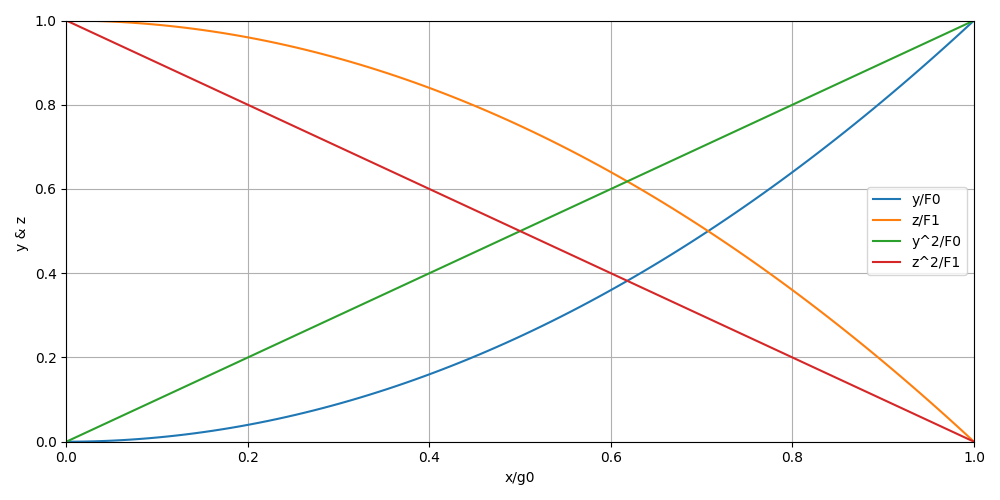

In [16]:
fig31, ax = plt.subplots(figsize=(10,5))
ax.plot(x, y, label=r'y/F0')
ax.plot(x, z, label=r'z/F1')
ax.plot(x_sq, y, label=r'y^2/F0')
ax.plot(x_sq, z, label=r'z^2/F1')
ax.set_xlabel('x/g0')
ax.set_ylabel('y & z ')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()